# UCI Heart Disease

Dataset-specific starting notebook for the DataFrameSampler paper experiments.

Claim-specific role: small medical classification benchmark with mixed clinical measurements and readable clinical categories.


## Setup

Run the downloader before executing this notebook:

```bash
python experiments/download_datasets.py
```

Dataset-specific choices live in `experiments/datasets.py`; the reusable execution path lives in `experiments/workflow.py`.


In [1]:
from pathlib import Path
import importlib
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "pyproject.toml").exists() and (candidate / "experiments").exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.datasets import DATASET_CONFIGS
from experiments.exploration import column_distribution_summary, plot_column_distribution_comparison, plot_pairwise_feature_comparison
import experiments.numeric_projection as numeric_projection
importlib.reload(numeric_projection)
from experiments.numeric_projection import numeric_view, plot_numeric_projection_triptych
from experiments.manifold_validation import summarize_manifold_validation
from experiments.mechanism_validation import summarize_decoder_calibration, summarize_mechanism_validation
from experiments.sensitivity_validation import summarize_sensitivity_validation
from experiments.predictive import predictive_performance_report, target_column_choice
from experiments.workflow import dataset_profile, experiment_paths, load_dataset, notebook_environment, run_configured_dataset_experiment, working_dataframe
from experiments.vectorization_plan import preprocessing_plan, vectorization_plan

DATASET_NAME = "heart_disease"
CONFIG = DATASET_CONFIGS[DATASET_NAME]
PATHS = experiment_paths(CONFIG, root=ROOT)
notebook_environment(PATHS)


{'python': '3.11.13',
 'pandas': '2.3.3',
 'dataset': '/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/data/processed/heart_disease.csv'}

## Load Prepared Data

Exploration uses the prepared source dataframe before the experiment workflow fits or samples anything.


In [2]:
dataframe = load_dataset(CONFIG, root=ROOT)
work = working_dataframe(dataframe, CONFIG)
profile = dataset_profile(dataframe)
dataframe.shape, dataframe.head()


((303, 14),
     age     sex        chest_pain  resting_blood_pressure  cholesterol  \
 0  63.0    male    typical_angina                   145.0        233.0   
 1  67.0    male      asymptomatic                   160.0        286.0   
 2  67.0    male      asymptomatic                   120.0        229.0   
 3  37.0    male  non_anginal_pain                   130.0        250.0   
 4  41.0  female   atypical_angina                   130.0        204.0   
 
   fasting_blood_sugar                   resting_ecg  max_heart_rate  \
 0           above_120  left_ventricular_hypertrophy           150.0   
 1       not_above_120  left_ventricular_hypertrophy           108.0   
 2       not_above_120  left_ventricular_hypertrophy           129.0   
 3       not_above_120                        normal           187.0   
 4       not_above_120  left_ventricular_hypertrophy           172.0   
 
   exercise_angina  oldpeak        slope  major_vessels               thal  \
 0              no      

## Target Column Choice

The predictive task uses this target column from the prepared dataframe.

In [3]:
target_column_choice(CONFIG, dataframe)


,target_column,task,available,unique,missing,note
0,heart_disease,classification,True,2,0,Configured in experiments/datasets.py and used...


## Dataset Profile

The reusable Heart Disease configuration runs on the full processed Cleveland table. The source multi-level diagnosis is converted into a binary heart-disease target during preparation.


In [4]:
profile


,dtype,missing,unique
age,float64,0,41
sex,object,0,2
chest_pain,object,0,4
resting_blood_pressure,float64,0,50
cholesterol,float64,0,152
fasting_blood_sugar,object,0,2
resting_ecg,object,0,3
max_heart_rate,float64,0,91
exercise_angina,object,0,2
oldpeak,float64,0,40


## Column Vectorization Plan

These are the columns that require vectorization before latent learning. The table records whether each column is numeric, directly mapped, discarded as high-cardinality, binary categorical, or NCA latent encoded to one numeric coordinate.


In [5]:
pre_plan = preprocessing_plan(CONFIG)
if not pre_plan.empty:
    display(pre_plan)

vector_plan = vectorization_plan(dataframe, CONFIG)
vector_plan[vector_plan["strategy"] == "categorical_nca"][
    ["column", "strategy", "latent_components", "high_cardinality_warning", "rationale"]
]


,column,strategy,latent_components,high_cardinality_warning,rationale
1,sex,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
2,chest_pain,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
5,fasting_blood_sugar,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
6,resting_ecg,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
8,exercise_angina,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
10,slope,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
12,thal,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
13,heart_disease,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."


## Exploratory Data Analysis

These cells summarize the original columns before the workflow runs. Original-vs-generated visual comparisons appear after `run_configured_dataset_experiment`, once generated rows are available.


In [6]:
column_distribution_summary(dataframe)


,column,dtype,missing_rate,unique,kind,mean,std,min,median,max,top_values
0,age,float64,0.000000,41,numeric,54.438944,9.038662,29.0,56.0,77.0,
1,sex,object,0.000000,2,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,male: 0.68; female: 0.32
2,chest_pain,object,0.000000,4,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,asymptomatic: 0.48; non_anginal_pain: 0.28; at...
3,resting_blood_pressure,float64,0.000000,50,numeric,131.689769,17.599748,94.0,130.0,200.0,
4,cholesterol,float64,0.000000,152,numeric,246.693069,51.776918,126.0,241.0,564.0,
5,fasting_blood_sugar,object,0.000000,2,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,not_above_120: 0.85; above_120: 0.15
6,resting_ecg,object,0.000000,3,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,normal: 0.50; left_ventricular_hypertrophy: 0....
7,max_heart_rate,float64,0.000000,91,numeric,149.607261,22.875003,71.0,153.0,202.0,
8,exercise_angina,object,0.000000,2,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,no: 0.67; yes: 0.33
9,oldpeak,float64,0.000000,40,numeric,1.039604,1.161075,0.0,0.8,6.2,


## Run Experiment

The full sampler/baseline workflow runs after the exploratory cells.


In [7]:
result = run_configured_dataset_experiment(CONFIG, root=ROOT)
result.paths


ExperimentPaths(root=PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler'), data_path=PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/data/processed/heart_disease.csv'), results_dir=PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/results'))

## Original vs Generated Visual Comparison

These plots overlay the working original dataframe and the generated DataFrameSampler rows using shared axes and different colors.


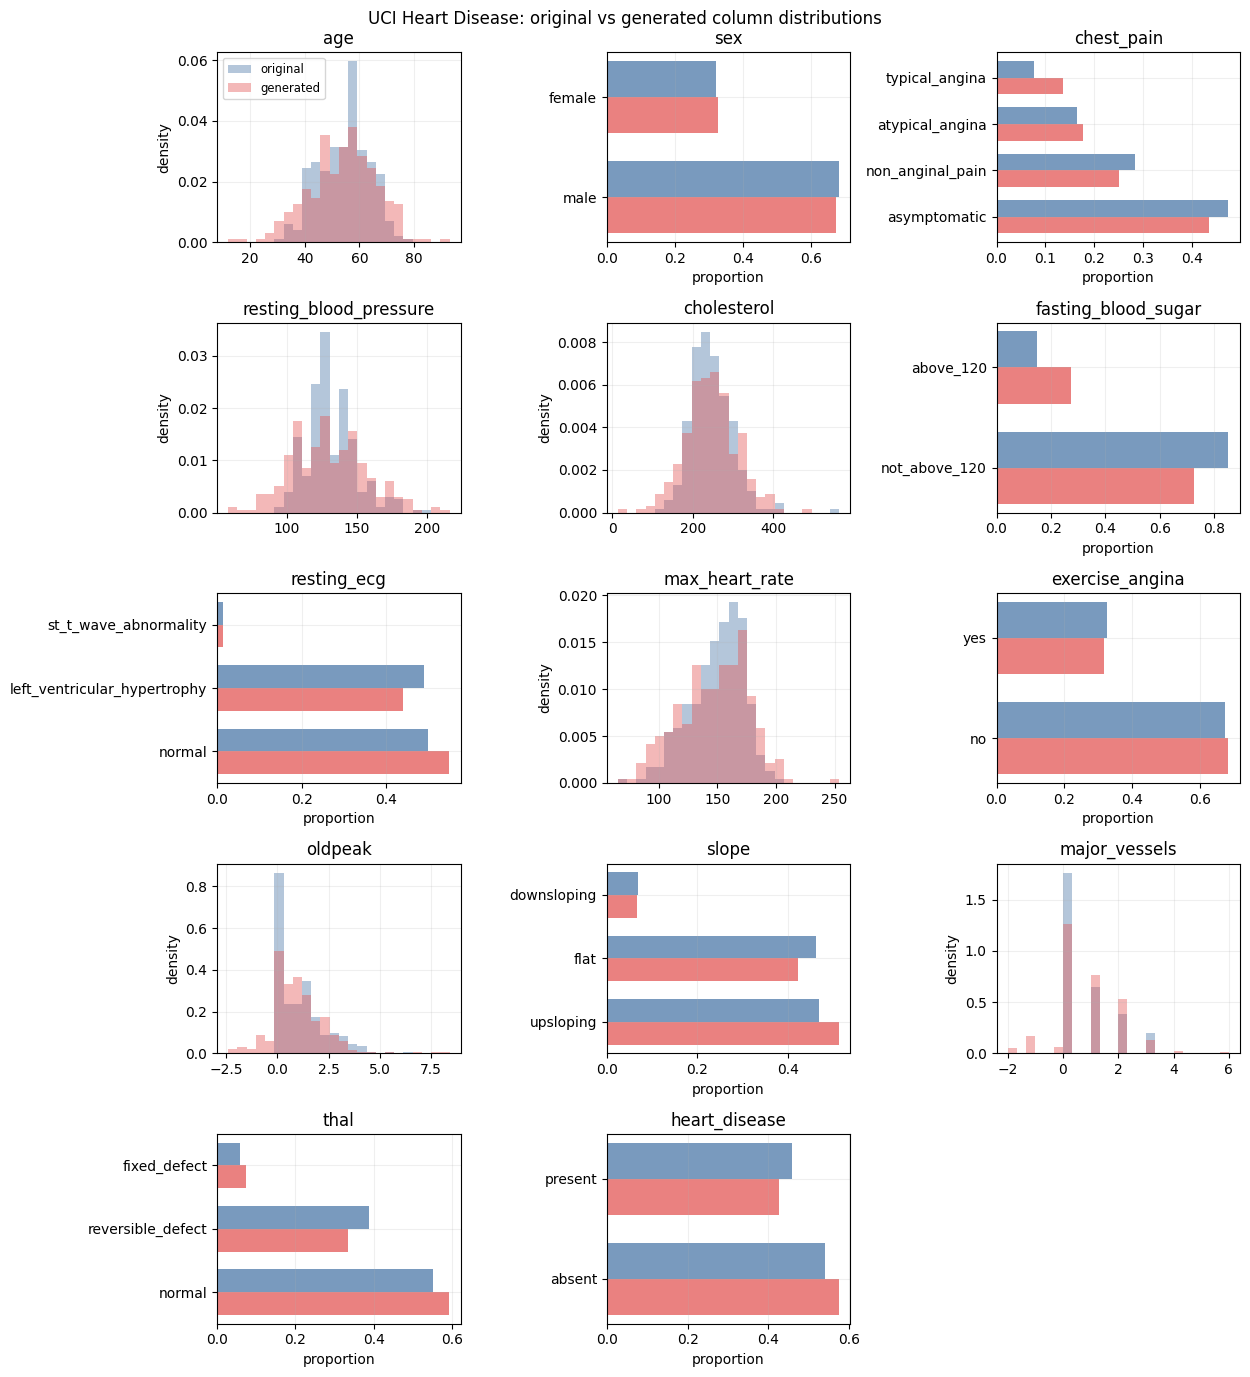

In [8]:
_ = plot_column_distribution_comparison(result.working_dataframe, result.starter_run.generated, title="UCI Heart Disease")


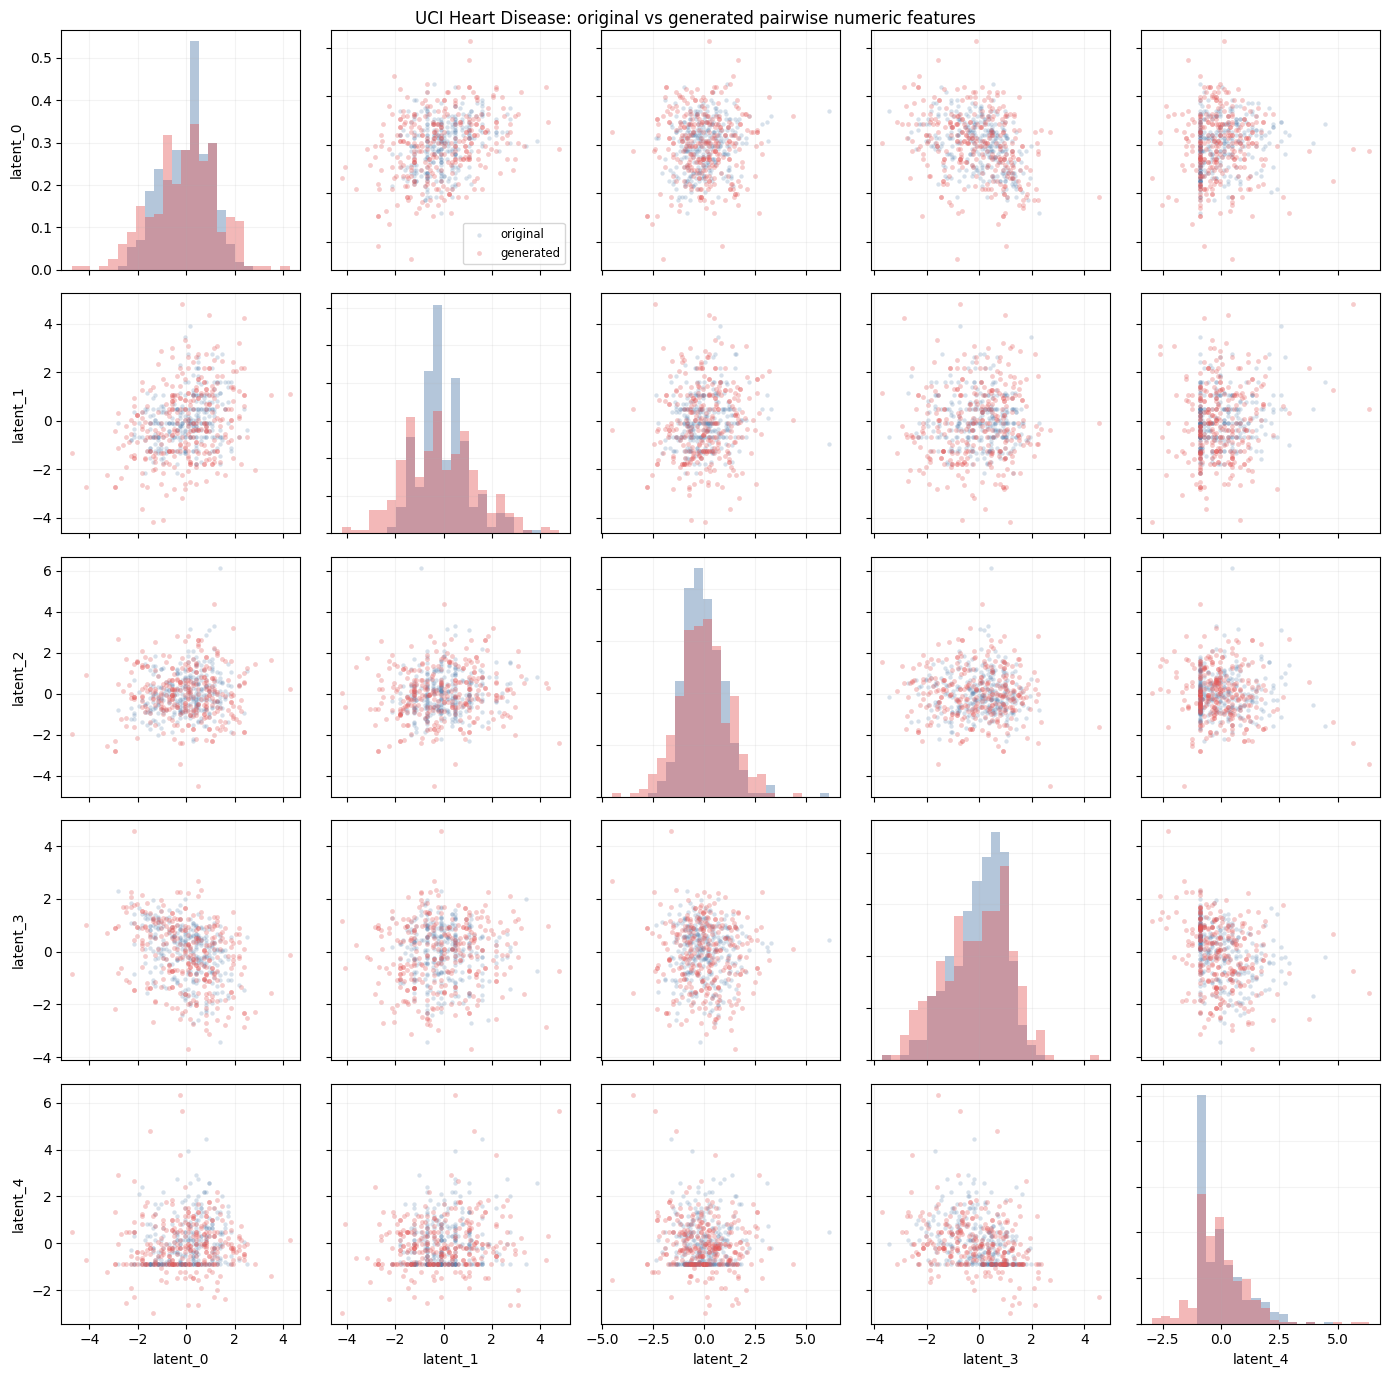

In [9]:
original_numeric = numeric_view(result.working_dataframe, result.starter_run.sampler)
generated_numeric = numeric_view(result.starter_run.generated, result.starter_run.sampler)
_ = plot_pairwise_feature_comparison(original_numeric, generated_numeric, target_column=CONFIG.target_column, title="UCI Heart Disease", max_numeric=None if "adult" == CONFIG.dataset_name else 5)


## Starter DataFrameSampler Run

The workflow writes the generated starter sample, quick similarity report, and runtime row to `experiments/results/`.


In [10]:
result.starter_run.fit_seconds, result.starter_run.sample_seconds, result.starter_run.generated.head()


(14.276912128960248,
 1.5910739870159887,
     age     sex        chest_pain  resting_blood_pressure  cholesterol  \
 0  75.0  female    typical_angina                   100.0        202.0   
 1  44.0    male  non_anginal_pain                   173.0        238.0   
 2  46.0    male      asymptomatic                    60.0        213.0   
 3  17.0  female      asymptomatic                    84.0        293.0   
 4  52.0    male      asymptomatic                   140.0         68.0   
 
   fasting_blood_sugar                   resting_ecg  max_heart_rate  \
 0       not_above_120  left_ventricular_hypertrophy           119.0   
 1       not_above_120  left_ventricular_hypertrophy           175.0   
 2       not_above_120                        normal           135.0   
 3       not_above_120  left_ventricular_hypertrophy           173.0   
 4           above_120                        normal           114.0   
 
   exercise_angina  oldpeak        slope  major_vessels               th

In [11]:
result.starter_run.similarity_report


,column,kind,real_mean,synthetic_mean,abs_mean_delta,real_missing,synthetic_missing,real_unique,synthetic_unique,category_coverage
0,age,numeric,54.438944,54.168317,0.270627,0.000000,0.0000,NaN,NaN,NaN
1,resting_blood_pressure,numeric,131.689769,130.009901,1.679868,0.000000,0.0000,NaN,NaN,NaN
2,cholesterol,numeric,246.693069,246.702970,0.009901,0.000000,0.0000,NaN,NaN,NaN
3,max_heart_rate,numeric,149.607261,146.953795,2.653465,0.000000,0.0000,NaN,NaN,NaN
4,oldpeak,numeric,1.039604,0.971947,0.067657,0.000000,0.0000,NaN,NaN,NaN
5,major_vessels,numeric,0.672241,0.696370,0.024129,0.013201,0.0000,NaN,NaN,NaN
6,sex,categorical,NaN,NaN,NaN,0.000000,0.0000,2.0,2.0,1.0
7,chest_pain,categorical,NaN,NaN,NaN,0.000000,0.0000,4.0,4.0,1.0
8,fasting_blood_sugar,categorical,NaN,NaN,NaN,0.000000,0.0000,2.0,2.0,1.0
9,resting_ecg,categorical,NaN,NaN,NaN,0.000000,0.0000,3.0,3.0,1.0


## Numeric Projection Of Generated Data

/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


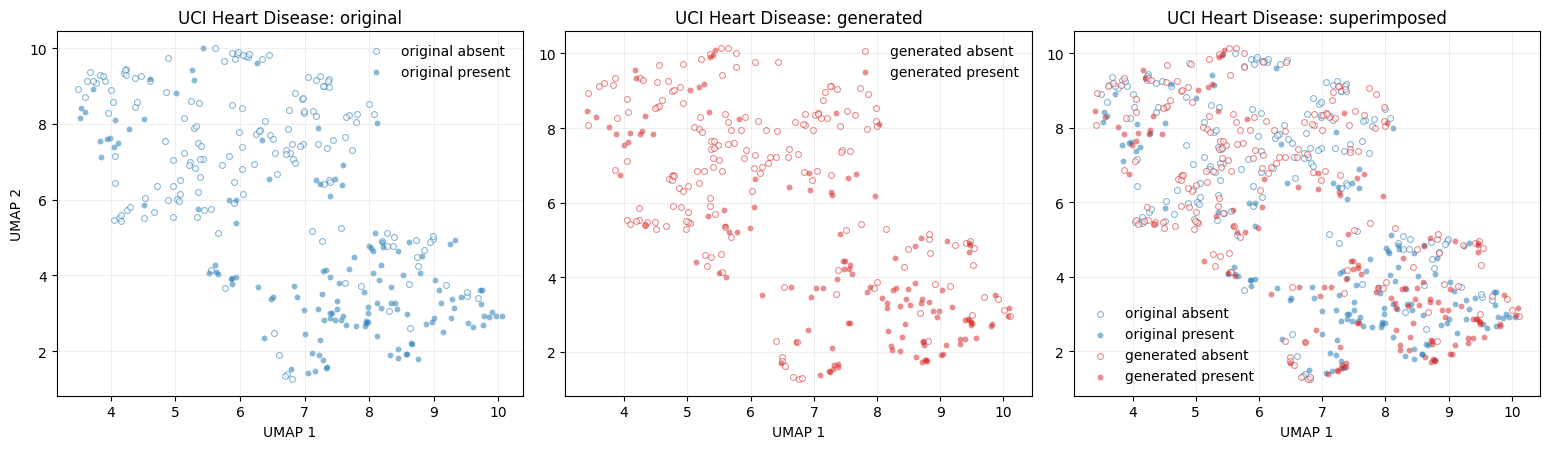

In [12]:
_ = plot_numeric_projection_triptych(
    result.starter_run.sampler,
    result.working_dataframe,
    result.starter_run.generated,
    target_column=CONFIG.target_column,
    title=CONFIG.title,
    reducer="umap",
    random_state=CONFIG.random_state,
)


## Baseline and Configuration Comparison

The same workflow runs DataFrameSampler and simple baselines and the simple baselines, then writes the comparison CSV.


In [13]:
result.comparison


,dataset,method,n_real,n_synthetic,numeric_mean_abs_error,numeric_std_abs_error,numeric_ks_statistic,numeric_wasserstein_distance,numeric_histogram_overlap,categorical_total_variation,...,discrimination_privacy_score,utility_task,utility_real_score,utility_augmented_score,utility_lift,distribution_histogram_overlap,distribution_numeric_kl,distribution_categorical_jsd,distribution_categorical_tv,distribution_similarity_score
0,heart_disease,dataframe_sampler,303,303,0.784274,5.266578,0.110206,4.929343,0.813739,0.049275,...,0.714286,classification,0.802198,0.780486,-0.021712,0.813739,0.190852,0.003926,0.049275,0.920179
1,heart_disease,gaussian_copula_empirical,303,303,0.715041,0.791809,0.046308,1.222574,0.925581,0.032197,...,0.626374,classification,0.802198,0.778107,-0.024091,0.925581,0.139924,0.001259,0.032197,0.964042
2,heart_disease,independent_columns,303,303,0.875944,0.156489,0.037750,1.490174,0.934288,0.020630,...,0.736264,classification,0.802198,0.780486,-0.021712,0.934288,0.197360,0.001385,0.020630,0.970758
3,heart_disease,row_bootstrap,303,303,0.423740,0.691601,0.035899,0.937161,0.936598,0.022296,...,0.703297,classification,0.802198,0.867842,0.065645,0.936598,0.077070,0.000576,0.022296,0.971242
4,heart_disease,stratified_columns,303,303,0.584857,0.951427,0.037957,1.206640,0.930351,0.025771,...,0.934066,classification,0.802198,0.813323,0.011125,0.930351,0.094125,0.000843,0.025771,0.967912


In [14]:
summarize_manifold_validation(result.manifold_validation)


,dataset,method,out_hull_rate,real_stress_median,real_stress_q95,generated_stress_median,out_hull_stress_median,out_hull_acceptance_at_real_q95
0,heart_disease,dataframe_sampler,1.0,0.04575,0.081792,0.044062,0.044062,0.944
1,heart_disease,latent_bootstrap,0.0,0.04575,0.081792,0.039368,NaN,NaN
2,heart_disease,latent_interpolation,0.0,0.04575,0.081792,0.041166,NaN,NaN


In [15]:
summarize_mechanism_validation(result.mechanism_validation)


,dataset,columns_evaluated,mean_cardinality,mean_nca_accuracy,mean_majority_accuracy,mean_pca_accuracy,mean_raw_context_accuracy,mean_lift_over_majority,mean_lift_over_pca
0,heart_disease,8,2.75,0.803571,0.574176,0.659341,0.751374,0.229396,0.144231


In [16]:
summarize_decoder_calibration(result.decoder_calibration)


,dataset,cardinality_bucket,columns_evaluated,mean_accuracy,mean_top_confidence,mean_confidence_gap,mean_negative_log_loss,mean_brier_score,mean_expected_calibration_error
0,heart_disease,binary,4,0.791209,0.820357,0.029148,0.421163,0.276468,0.070742
1,heart_disease,low,4,0.714286,0.708599,-0.005687,0.795082,0.369098,0.088214


## Predictive Target Evaluation

The real data is split into train/test rows. The sampler is fit only on the real training rows, then real train, real test, and synthetic-from-train rows are reduced to the sampler numeric view. The table compares a predictor trained on real training rows with one trained only on generated rows, both tested on the same real test rows.

In [17]:
predictive_report = predictive_performance_report(work, CONFIG)
predictive_report


,dataset,target_column,task,training_source,accuracy,balanced_accuracy,f1_weighted,roc_auc,mae,rmse,r2,train_rows,test_rows
0,heart_disease,heart_disease,classification,real_train,0.780220,0.775510,0.779035,0.897473,NaN,NaN,NaN,212,91
1,heart_disease,heart_disease,classification,synthetic_from_real_train,0.802198,0.797619,0.801131,0.909621,NaN,NaN,NaN,212,91


In [18]:
summarize_sensitivity_validation(result.sensitivity_validation)


,parameter,value,setup_label,datasets_evaluated,n_iterations,max_constraint_retries,calibrate_decoders,mean_nn_distance_ratio,mean_discrimination_accuracy,mean_utility_lift,mean_distribution_similarity_score,mean_fit_seconds,mean_sample_seconds
